# Ablation analysis

Reads every `test_classification_metrics.json` directly under `experiments/` (skipping the `0.2_val/` and `0.5_val/` baseline folders) and produces:

- A master sorted table (markdown).
- Grouped views: loss/sampler ablation, warm-up/TSFEL-dropout ablation.
- Bar plots per group.
- Comparison with the previous baselines in `0.2_val/`.

**Note:** the `abl_warmup_encoder` runs are missing — the ablation script looked for the deep-only checkpoint at the wrong path (no `0.2_val/` prefix, and `bs=2048` instead of `bs=512`).

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
EXPERIMENTS_DIR = REPO_ROOT / 'experiments'
EXCLUDE_DIRS = {'0.2_val', '0.5_val', 'dryrun', 'ablations'}
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

In [2]:
def parse_run_name(name: str) -> dict:
    """Best-effort: split name into model, mode, suffix."""
    parts = name.split('_')
    # Models can have underscore (cnn_lstm, tsfel_mlp). Detect by prefix.
    if name.startswith('cnn_lstm_'):
        model, rest = 'cnn_lstm', name[len('cnn_lstm_'):]
    elif name.startswith('tsfel_mlp_'):
        model, rest = 'tsfel_mlp', name[len('tsfel_mlp_'):]
    else:
        model, rest = parts[0], '_'.join(parts[1:])
    # Mode is the next token (hybrid, deep_only, tsfel_only). tsfel_only has underscore.
    for mode in ('tsfel_only', 'deep_only', 'hybrid'):
        if rest.startswith(mode + '_'):
            suffix_and_rest = rest[len(mode) + 1:]
            # Strip the AcTBeCalf_epN_bsN_lrX_sN tail.
            m = re.search(r'_AcTBeCalf_ep\d+_bs\d+_lr', suffix_and_rest)
            suffix = suffix_and_rest[:m.start()] if m else suffix_and_rest
            return {'model': model, 'mode': mode, 'suffix': suffix}
    return {'model': model, 'mode': '?', 'suffix': rest}

def collect(exp_dir: Path) -> pd.DataFrame:
    rows = []
    for d in sorted(exp_dir.iterdir()):
        if not d.is_dir() or d.name in EXCLUDE_DIRS:
            continue
        f = d / 'test_classification_metrics.json'
        if not f.is_file():
            continue
        data = json.loads(f.read_text()).get('overall', {})
        info = parse_run_name(d.name)
        info.update({
            'name': d.name,
            'accuracy': data.get('accuracy'),
            'f1_macro': data.get('f1_macro'),
            'f1_weighted': data.get('f1_weighted'),
        })
        rows.append(info)
    return pd.DataFrame(rows)

df = collect(EXPERIMENTS_DIR)
df_baseline = collect(EXPERIMENTS_DIR / '0.2_val')
df_baseline['suffix'] = '(baseline 0.2_val)'
print(f'Ablations: {len(df)} runs | 0.2_val baselines: {len(df_baseline)} runs')

Ablations: 22 runs | 0.2_val baselines: 13 runs


## Master table (sorted by F1 macro desc)

In [3]:
df_sorted = df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(df_sorted[['model', 'mode', 'suffix', 'accuracy', 'f1_macro', 'f1_weighted']].round(4))

,model,mode,suffix,accuracy,f1_macro,f1_weighted
0,robust,hybrid,abl_baseline,0.6566,0.3436,0.6505
1,robust,hybrid,abl_tsfel_dropout25,0.6543,0.3400,0.6482
2,robust,hybrid,abl_curriculum10,0.6424,0.3385,0.6402
3,patchtst,hybrid,lossce,0.6234,0.3308,0.6512
4,cnn_lstm,hybrid,abl_tsfel_dropout25,0.6830,0.3300,0.6717
5,cnn_lstm,hybrid,abl_curriculum10,0.6779,0.3260,0.6641
6,cnn_lstm,hybrid,abl_baseline,0.6742,0.3249,0.6659
7,cnn_lstm,hybrid,lossce,0.5886,0.3007,0.6296
8,tsfel_mlp,tsfel_only,lossce,0.5793,0.2989,0.6260
9,patchtst,hybrid,lossce_balsamp,0.5171,0.2969,0.5638


## Tagging ablation type

In [4]:
def ablation_type(suffix: str) -> str:
    if suffix.startswith('abl_'):
        return 'warmup_ablation'
    if suffix.startswith('loss'):
        return 'loss_ablation'
    return 'other'

df['ablation'] = df['suffix'].apply(ablation_type)
df.groupby('ablation').size()

ablation
loss_ablation      16
warmup_ablation     6
dtype: int64

## Loss/sampler ablation

In [5]:
df_loss = (
    df[df['ablation'] == 'loss_ablation']
    .sort_values(['model', 'suffix'])
    .reset_index(drop=True)
)
pivot = df_loss.pivot_table(
    index='model', columns='suffix', values='f1_macro', aggfunc='first'
).round(4)
display(pivot)

suffix,lossce,lossce_balsamp,lossfocal,lossfocal_balsamp
model,,,,
cnn_lstm,0.3007,0.2016,0.2567,0.1805
patchtst,0.3308,0.2969,0.2710,0.2516
robust,0.2906,0.2214,0.2785,0.1886
tsfel_mlp,0.2989,0.1580,0.2590,0.1498


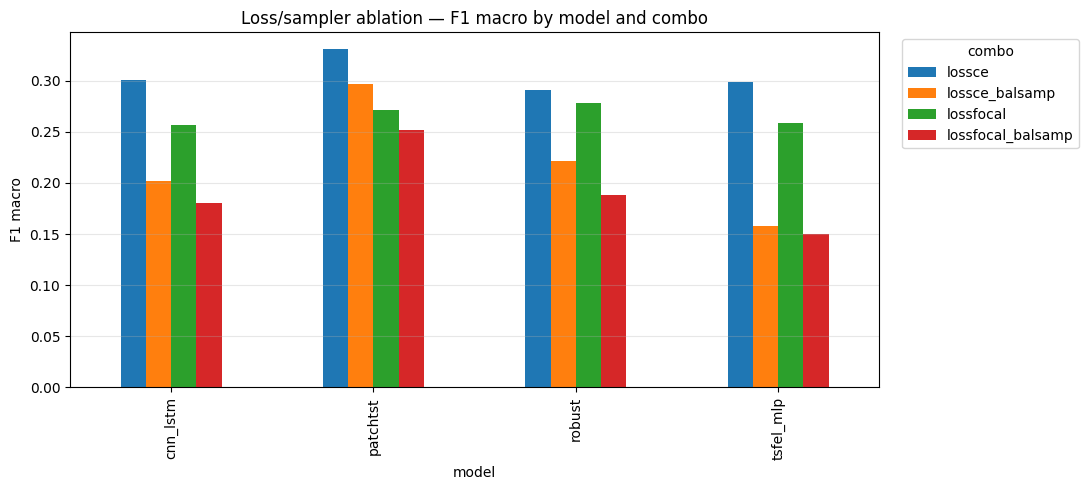

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('F1 macro')
ax.set_title('Loss/sampler ablation — F1 macro by model and combo')
ax.legend(title='combo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Warmup / TSFEL-dropout ablation

suffix,abl_baseline,abl_curriculum10,abl_tsfel_dropout25
model,,,
cnn_lstm,0.3249,0.3260,0.33
robust,0.3436,0.3385,0.34


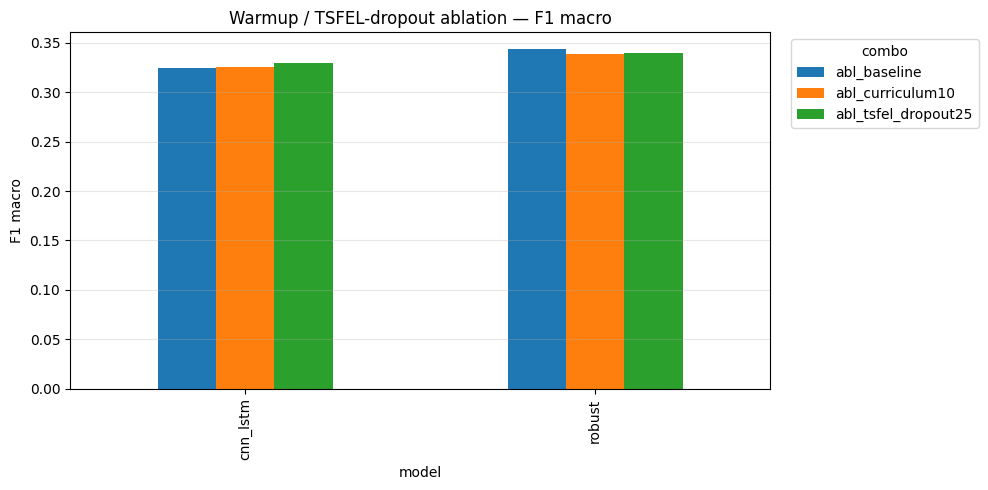

In [7]:
df_warm = (
    df[df['ablation'] == 'warmup_ablation']
    .sort_values(['model', 'suffix'])
    .reset_index(drop=True)
)
pivot_warm = df_warm.pivot_table(
    index='model', columns='suffix', values='f1_macro', aggfunc='first'
).round(4)
display(pivot_warm)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_warm.plot(kind='bar', ax=ax)
ax.set_ylabel('F1 macro')
ax.set_title('Warmup / TSFEL-dropout ablation — F1 macro')
ax.legend(title='combo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison vs `0.2_val/` baselines

In [8]:
df_bl = df_baseline[df_baseline['suffix'] == '(baseline 0.2_val)'].copy()
df_bl['key'] = df_bl['model'] + '/' + df_bl['mode']
bl_lookup = df_bl.set_index('key')['f1_macro']

df['key'] = df['model'] + '/' + df['mode']
df['delta_vs_baseline'] = df['f1_macro'] - df['key'].map(bl_lookup)

view = df.sort_values('delta_vs_baseline', ascending=False)[
    ['model', 'mode', 'suffix', 'f1_macro', 'delta_vs_baseline']
].round(4)
display(view)

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

## Markdown table (for the paper / report)

In [ ]:
table = df_sorted[['name', 'accuracy', 'f1_macro', 'f1_weighted']].copy()
table.columns = ['Model', 'Accuracy', 'F1 Macro', 'F1 Weighted']
md = table.to_markdown(index=False, floatfmt='.4f')
out_path = REPO_ROOT / 'notebooks' / 'ablation_results.md'
out_path.write_text(f'# Ablation results\n\n{md}\n')
print(f'wrote {out_path}')
print()
print(md)